In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.max_column',None) ##ye use kiye hai jisme sb columns show ho koi bhi missing na ho

In [4]:
df=pd.read_csv("Online Retail.csv")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [7]:
df.shape ##ye rows or columns kitne hai ye bata rha

(541909, 8)

In [8]:
df.columns ###kon kon se columns hai uska nam dega 

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


In [10]:
df.describe() #max kitna quantity ka unit price ka avg koi outliers ye sb btaata hai 

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,15287.518434
std,218.081158,96.759853,1484.746041
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,14367.000000
50%,3.000000,2.080000,15287.000000
75%,10.000000,4.130000,16255.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
df.isnull().sum() ##ye missig value batati hai

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

In [12]:
df['CustomerID'].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: CustomerID, Length: 541909, dtype: bool

In [13]:
df['Description'].isnull().sum()

np.int64(1454)

In [14]:
missing = (df.isnull().sum() / len(df))*100

missing.sort_values(ascending=False)

Description    0.268311
InvoiceNo      0.000000
StockCode      0.000000
Quantity       0.000000
InvoiceDate    0.000000
UnitPrice      0.000000
CustomerID     0.000000
Country        0.000000
dtype: float64

In [15]:
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,15287,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,15287,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,15287,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,15287,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,15287,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,15287,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,15287,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,15287,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,15287,United Kingdom


In [16]:
df[df['Description'].isnull()].describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,1454,1454,0,1454.000000,1454,1454.0,1454.0,1454
unique,1454,960,0,NaN,1121,NaN,NaN,1
top,536414,23084,NaN,NaN,2010-12-09 15:57:00,NaN,NaN,United Kingdom
freq,1,10,NaN,NaN,5,NaN,NaN,1454
mean,NaN,NaN,NaN,-9.359697,NaN,0.0,15287.0,NaN
std,NaN,NaN,NaN,243.238758,NaN,0.0,0.0,NaN
min,NaN,NaN,NaN,-3667.000000,NaN,0.0,15287.0,NaN
25%,NaN,NaN,NaN,-24.000000,NaN,0.0,15287.0,NaN
50%,NaN,NaN,NaN,-3.000000,NaN,0.0,15287.0,NaN
75%,NaN,NaN,NaN,4.000000,NaN,0.0,15287.0,NaN


In [17]:
df[df['CustomerID']==15287]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,15287,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,15287,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,15287,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,15287,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,15287,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,15287,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,15287,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,15287,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,15287,United Kingdom


In [17]:
df['CustomerID'].nunique()

4372

In [18]:
df['CustomerID'].value_counts().head(10)

CustomerID
15287    135101
17841      7983
14911      5903
14096      5128
12748      4642
14606      2782
15311      2491
14646      2085
13089      1857
13263      1677
Name: count, dtype: int64

In [18]:
df[df['CustomerID']==15287]['InvoiceNo'].nunique()

3713

In [ ]:
######Dataset contains 4372 unique customers.

##CustomerID 15287 appears disproportionately often (135,101 rows) and is associated with both normal sales records and records having missing descriptions.

##Further investigation is required to determine whether this represents an unusually active customer, grouped transactions, or a special business account.#####

In [19]:
df.duplicated().sum()

np.int64(5268)

In [20]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [21]:
df[df.duplicated()].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920,United Kingdom


In [22]:
df[df.duplicated(keep=False)].sort_values(
    by=['InvoiceNo', 'StockCode']
).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920,United Kingdom


In [23]:
df_clean = df.copy()

In [24]:
df_clean=df_clean.drop_duplicates()

In [25]:
df_clean.duplicated().sum()

np.int64(0)

In [26]:
print('Original_shape:',df.shape)
print('clean_shape',df_clean.shape)

Original_shape: (541909, 8)
clean_shape (536641, 8)


In [ ]:
##Duplicate analysis identified 5,268 exact duplicate records in the dataset.
##Investigation confirmed that these records were identical across all available columns, including Invoice Number, Stock Code, Description, Quantity, Invoice Date, Unit Price, Customer ID, and Country. 
##Since these duplicates did not provide any additional business information and could potentially bias future analysis, they were removed after creating a backup copy of the original dataset.##
##The cleaned dataset will be used for all subsequent analyses.

In [27]:
df_clean['Sales']=df_clean['Quantity']*df_clean['UnitPrice']

In [28]:
df_clean.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
##A new feature named Sales was created by multiplying Quantity with UnitPrice. 
##This feature represents the revenue generated from each transaction and will serve as the primary business metric for further analysis,
##including customer behavior, product performance, sales trends, revenue forecasting, dashboard development, and machine learning models.

In [29]:
df_clean['Sales'].describe()

count    536641.000000
mean         18.123861
std         380.656263
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Sales, dtype: float64

In [ ]:
#### Sales Descriptive Statistics Analysis

##The descriptive statistics of the Sales feature provide an initial understanding of transaction values in the retail dataset. The dataset contains 536,641 valid sales records, confirming that the Sales feature was successfully created for all transactions. The average sales value is 18.12, whereas the median sales value is 9.87. Since the mean is considerably higher than the median, the distribution of sales is positively skewed, indicating the presence of a few high-value transactions that increase the overall average. The standard deviation of 380.66 suggests substantial variability in transaction values, meaning that sales are not evenly distributed across transactions. The minimum sales value (-168,469.60) indicates product returns or cancelled transactions, while the maximum sales value (168,469.60) represents an exceptionally large transaction that should be investigated further. Additionally, 25% of the transactions have sales values less than or equal to 3.75, and 75% of the transactions have sales values less than or equal to 17.40, indicating that most transactions are relatively small while only a limited number of transactions contribute very large sales amounts. Overall, the descriptive statistics reveal the presence of outliers, high variability, and return transactions, all of which should be considered during further business analysis.

In [30]:
df_clean['InvoiceDate'].dtype

dtype('O')

In [31]:
df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])

In [32]:
df_clean['InvoiceDate'].dtype

dtype('<M8[ns]')

In [33]:
df_clean['Year']=df_clean['InvoiceDate'].dt.year

In [34]:
df_clean['Month']=df_clean['InvoiceDate'].dt.month

In [35]:
df_clean['Month_Name']=df_clean['InvoiceDate'].dt.month_name()

In [36]:
df_clean['Day']=df_clean['InvoiceDate'].dt.day

In [37]:
df_clean['Weekday']=df_clean['InvoiceDate'].dt.day_name()

In [38]:
df_clean['Hour']=df_clean['InvoiceDate'].dt.hour

In [39]:
#### InvoiceDate Data Type Conversion

##The `InvoiceDate` column was initially stored as an object (string) data type instead of a datetime format. Since date-based analysis such as extracting year, month, weekday, and hour cannot be performed on string data, the column was converted into datetime format using the `pd.to_datetime()` function. This conversion enables efficient time-series analysis and supports advanced feature engineering for business insights.

In [40]:
df_clean[['InvoiceDate','Year','Month','Month_Name','Day','Weekday','Hour']].head(10)

,InvoiceDate,Year,Month,Month_Name,Day,Weekday,Hour
0,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
1,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
2,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
3,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
4,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
5,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
6,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8
7,2010-12-01 08:28:00,2010,12,December,1,Wednesday,8
8,2010-12-01 08:28:00,2010,12,December,1,Wednesday,8
9,2010-12-01 08:34:00,2010,12,December,1,Wednesday,8


Business KPI Analysis


Total Revenue Analysis



How much net revenue did the business generate during the available transaction period after considering both completed sales and returned/cancelled transactions?

In [41]:
total_revenue = df_clean['Sales'].sum()

print(f"Total Net Revenue : {total_revenue:,.2f}")

Total Net Revenue : 9,726,006.95


In [42]:
###The company achieved a significant level of sales during the analysis period. 
##However, additional investigation is required to determine how much revenue was reduced due to product returns and cancellations before evaluating overall business performance.

KPI 
Revenue Breakdown analysis
How is the total revenue distributed between completed sales and returned/cancelled transactions, and what percentage of revenue was affected by returns

In [43]:
gross_revenue=df_clean[df_clean['Sales']>0]['Sales'].sum()
print(f"Gross_revenue:{gross_revenue:,.2f}")

Gross_revenue:10,642,110.80


In [44]:
return_revenue=df_clean[df_clean['Sales']<0]['Sales'].sum()
print(f"Return_revenue:{return_revenue:,.2f}")

Return_revenue:-916,103.85


In [45]:
return_percentage=(abs(return_revenue)/gross_revenue)*100
print(f"Return_Percentage:{return_percentage:,.2f}")

Return_Percentage:8.61


In [46]:
#### Business Interpretation

##The business generated a **Gross Revenue of 10,642,110.80** during the analysis period. However, products worth **916,103.85** were returned or cancelled, reducing the company's overall sales. After accounting for these returns, the business achieved a **Net Revenue of 9,726,006.95**. The analysis also shows that **8.61%** of the gross revenue was impacted by returned or cancelled transactions, indicating that returns had a measurable effect on overall business revenue.


#Customer Analysis
#How many unique customers made purchases during the available transaction period?

In [47]:
total_customers=df_clean['CustomerID'].nunique()
print(f"Total_Customer:{total_customers}")

Total_Customer:4372


In [48]:
###The dataset contains 4,372 unique customers who made purchases during the analysis period. This represents the active customer base available for analysis. Since each customer may have placed multiple orders,
###the number of transactions is significantly higher than the number of unique customers.
##The business served 4,372 distinct customers during the observed period. This customer base forms the foundation for further analysis, including customer purchase frequency, revenue contribution, repeat buying behavior, customer segmentation, and loyalty analysis

In [49]:
##How many unique orders were placed during the available transaction period?

In [50]:
total_orders = df_clean['InvoiceNo'].nunique()
print(f"Total Orders : {total_orders}")

Total Orders : 25900


In [51]:
##On average, how many orders did each customer place during the analysis period?

In [52]:
average_orders_per_customer = total_orders / total_customers
print(f"Average Orders per Customer : {average_orders_per_customer:.2f}")

Average Orders per Customer : 5.92


Who are the top 10 customers contributing the highest revenue to the business?

In [53]:
top_customers = (
    df_clean
    .groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
15287    1447972.77
14646     279489.02
18102     256438.49
17450     187322.17
14911     132458.73
12415     123725.45
14156     113214.59
17511      88125.38
16684      65892.08
13694      62690.54
Name: Sales, dtype: float64

In [54]:
df_clean[df_clean['CustomerID']==15287]['InvoiceNo'].nunique()

3713

In [55]:
df_clean[df_clean['CustomerID']==15287].shape

(135058, 15)

In [56]:
df_clean[df_clean['CustomerID']==15287]['Quantity'].sum()

np.int64(270083)

In [57]:
customer_15287 = df_clean[df_clean['CustomerID']==15287]
customer_15287.groupby('InvoiceNo')['Sales'].sum().mean()

np.float64(389.97381362779424)

In [58]:
#### Observation

##Customer **15287** generated significantly higher revenue than any other customer in the dataset. Further investigation revealed that this customer placed **3,713 unique orders**, accounting for approximately **14.3%** of all orders, and contributed **135,058 transaction records**, nearly **25%** of the dataset.

##While this behavior appears unusual compared to other customers, there is currently no evidence confirming that these records are incorrect. The customer may represent a high-volume wholesale buyer, an internal business account, or another legitimate business entity.

##Therefore, the customer has **not been removed** from the dataset. This observation will be revisited during the outlier and customer distribution analysis stages before making any data-cleaning decisions.

In [59]:
##What percentage of the total revenue is contributed by the top 10 customers?


In [60]:
top10_revenue = top_customers.sum()
print(top10_revenue)

2757329.22


In [61]:
top10_contribution = (top10_revenue / total_revenue) * 100
print(f"Top 10 Customer Revenue Contribution : {top10_contribution:.2f}%")

Top 10 Customer Revenue Contribution : 28.35%


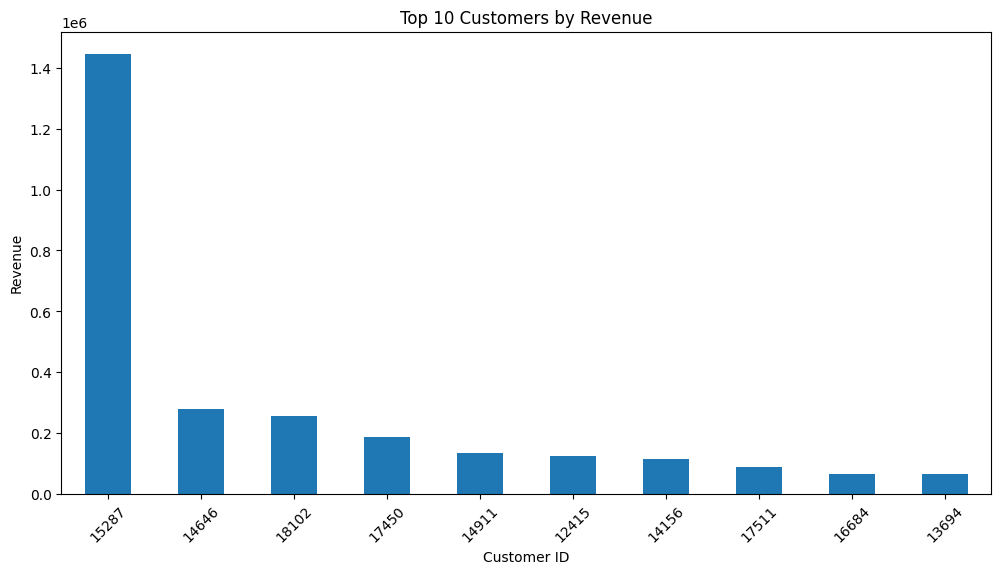

In [62]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [63]:
customer_frequency = (
    df_clean
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

customer_frequency.head(10)

CustomerID
15287    3713
14911     248
12748     224
17841     169
14606     128
15311     118
13089     118
12971      89
14527      86
13408      81
Name: InvoiceNo, dtype: int64

In [64]:
one_time_customers = (customer_frequency == 1).sum()
print("One-Time Customers :", one_time_customers)

One-Time Customers : 1313


In [65]:
repeat_customers = (customer_frequency > 1).sum()
print("Repeat Customers :", repeat_customers)

Repeat Customers : 3059


In [66]:
repeat_rate = (repeat_customers / total_customers) * 100
print(f"Repeat Customer Rate : {repeat_rate:.2f}%")

Repeat Customer Rate : 69.97%


In [67]:
def customer_segment(order):

    if order == 1:
        return "One-Time Buyer"

    elif order <= 5:
        return "Occasional Buyer"

    elif order <= 10:
        return "Regular Buyer"

    elif order <= 20:
        return "Loyal Buyer"

    else:
        return "VIP Buyer"

In [68]:
customer_segments = customer_frequency.apply(customer_segment)
customer_segments.head(10)

CustomerID
15287    VIP Buyer
14911    VIP Buyer
12748    VIP Buyer
17841    VIP Buyer
14606    VIP Buyer
15311    VIP Buyer
13089    VIP Buyer
12971    VIP Buyer
14527    VIP Buyer
13408    VIP Buyer
Name: InvoiceNo, dtype: object

In [69]:
segment_summary = customer_segments.value_counts()

print(segment_summary)

InvoiceNo
Occasional Buyer    1971
One-Time Buyer      1313
Regular Buyer        628
Loyal Buyer          317
VIP Buyer            143
Name: count, dtype: int64


In [70]:
segment_percentage = round((segment_summary / total_customers) * 100, 2)
print(segment_percentage)

InvoiceNo
Occasional Buyer    45.08
One-Time Buyer      30.03
Regular Buyer       14.36
Loyal Buyer          7.25
VIP Buyer            3.27
Name: count, dtype: float64


Which customer segment contains the highest number of customers?

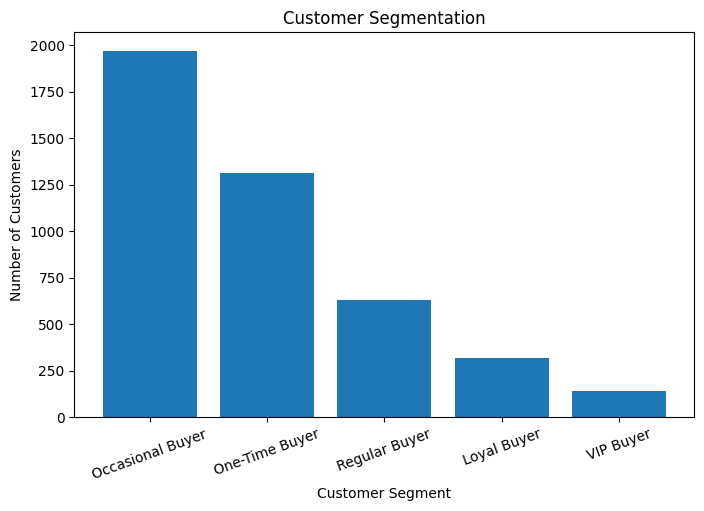

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(segment_summary.index, segment_summary.values)

plt.title("Customer Segmentation")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

What percentage of customers belong to each customer segment?

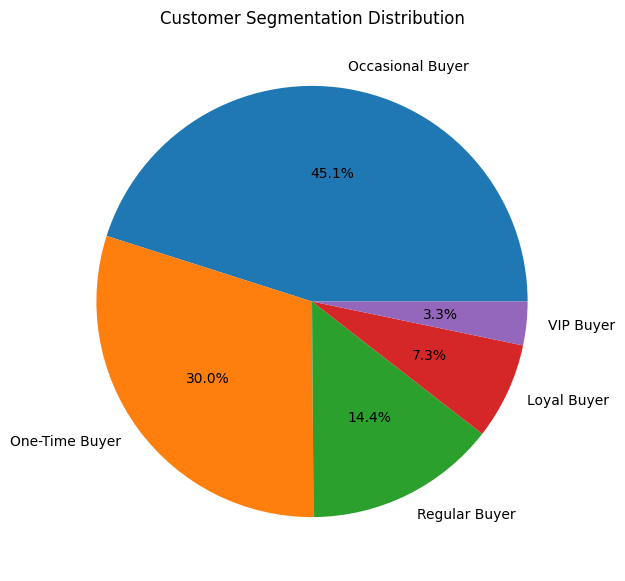

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))
plt.pie(
    segment_summary.values,
    labels=segment_summary.index,
    autopct='%1.1f%%'
)
plt.title("Customer Segmentation Distribution")
plt.show()

PRODUCT ANALYSIS

How many unique products are available in the dataset

In [73]:
total_products=df_clean['StockCode'].nunique()
print("Total_unique_products:",total_products)

Total_unique_products: 4070


In [74]:
top_products=df_clean.groupby("Description")["Quantity"].sum()
top_products=top_products.sort_values(ascending=False)
top_products.head()

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53751
JUMBO BAG RED RETROSPOT              47260
POPCORN HOLDER                       36322
ASSORTED COLOUR BIRD ORNAMENT        36282
PACK OF 72 RETROSPOT CAKE CASES      36016
Name: Quantity, dtype: int64

In [75]:
##Products are grouped by their description, and the total quantity sold for each product is calculated. The results are then sorted in descending order to identify the top-selling products.

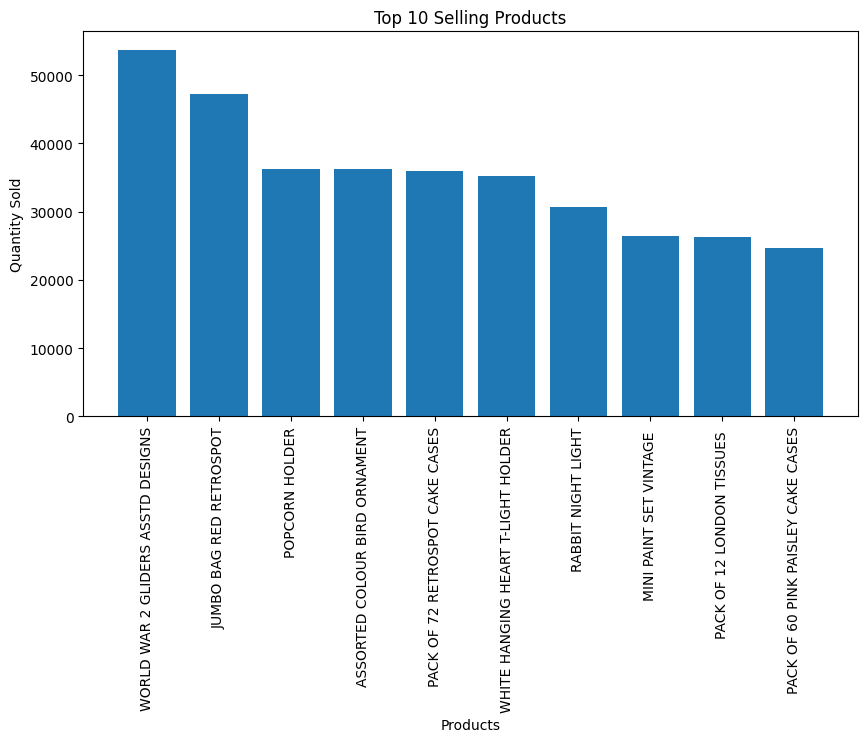

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top_products.head(10).index,
        top_products.head(10).values)

plt.title("Top 10 Selling Products")

plt.xlabel("Products")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)
plt.show()

Which products generated the highest revenue?

In [77]:
top_revenue_products=df_clean.groupby('Description')['Sales'].sum()
top_revenue_products=top_revenue_products.sort_values(ascending=False)
top_revenue_products.head()

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
Name: Sales, dtype: float64

Time Analysis

In [78]:
monthly_revenue = (
    df_clean.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
)
monthly_revenue

,Year,Month,Sales
0,2010,12,746723.610
1,2011,1,558448.560
2,2011,2,497026.410
3,2011,3,682013.980
4,2011,4,492367.841
5,2011,5,722094.100
6,2011,6,689977.230
7,2011,7,680156.991
8,2011,8,681386.460
9,2011,9,1017596.682


In [79]:
##"Business maintained relatively stable revenue during the first eight months of 2011. From September onward, revenue increased significantly and reached its peak in November, indicating strong seasonal demand. The lower revenue in December 2011 is likely due to incomplete data rather than an actual decline in business performance."

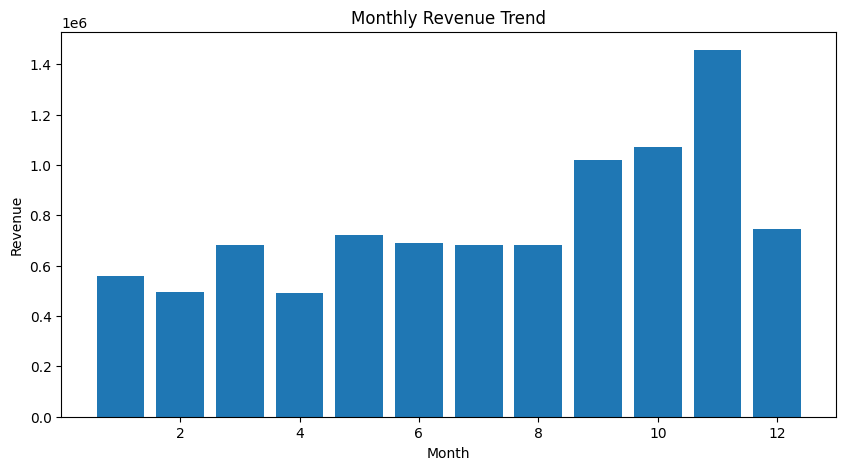

In [80]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(monthly_revenue['Month'],
         monthly_revenue['Sales'])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [81]:
monthly_orders = (
    df_clean.groupby(['Year', 'Month'])['InvoiceNo'] .nunique().reset_index()
)
monthly_orders

,Year,Month,InvoiceNo
0,2010,12,2025
1,2011,1,1476
2,2011,2,1393
3,2011,3,1983
4,2011,4,1744
5,2011,5,2162
6,2011,6,2012
7,2011,7,1927
8,2011,8,1737
9,2011,9,2327


In [82]:
##The increase in both revenue and order volume during the final quarter indicates strong seasonal demand. The business should prepare inventory, staffing, and marketing campaigns before the holiday season to maximize sales opportunities.

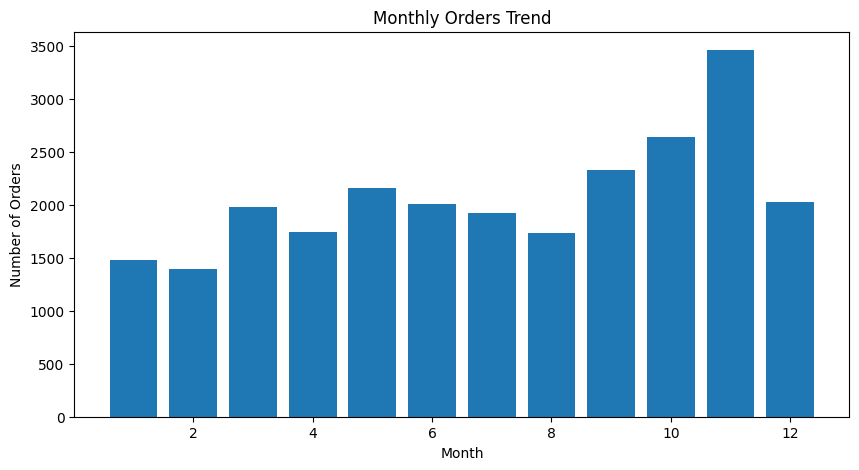

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    monthly_orders['Month'],
    monthly_orders['InvoiceNo']
)

plt.title("Monthly Orders Trend")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.show()

In [84]:
country_revenue = (
    df_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Sales, dtype: float64

#Which countries generated the highest revenue?


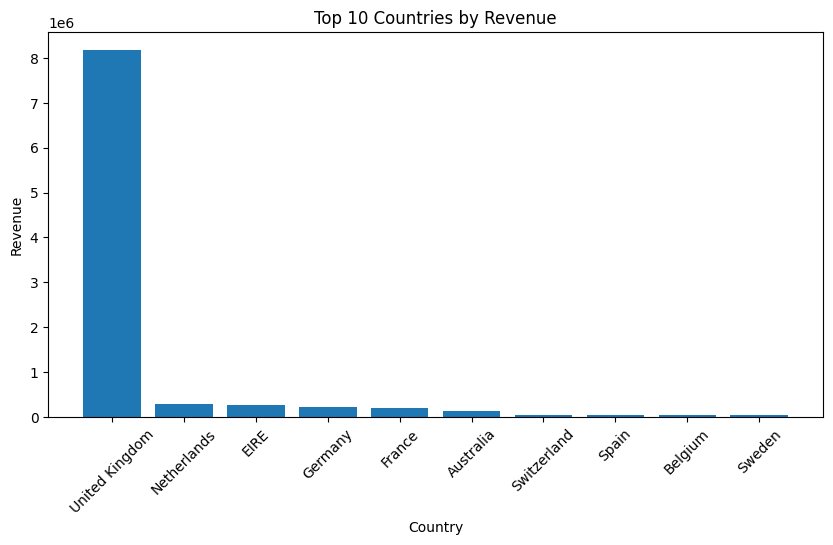

In [85]:
import matplotlib.pyplot as plt

top10_country = country_revenue.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10_country.index,
    top10_country.values
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [86]:
#What percentage of total revenue comes from the United Kingdom?

In [87]:
uk_revenue = df_clean[df_clean['Country'] == 'United Kingdom']['Sales'].sum()
uk_revenue

np.float64(8167128.184)

In [88]:
uk_percentage = (uk_revenue / total_revenue) * 100

print(f"United Kingdom Revenue Contribution: {uk_percentage:.2f}%")

United Kingdom Revenue Contribution: 83.97%


In [89]:
#How much of the total revenue is contributed by the Top 10 countries?

In [90]:
top10_revenue = country_revenue.head(10).sum()

top10_revenue

np.float64(9459234.904000001)

In [91]:
top10_percentage = (top10_revenue / total_revenue) * 100

print(f"Top 10 Countries Revenue Contribution: {top10_percentage:.2f}%")

Top 10 Countries Revenue Contribution: 97.26%


#RFM


In [92]:
df_clean['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [93]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [94]:
def calculate_recency(x):
    return (reference_date - x.max()).days

In [95]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': calculate_recency,
    'InvoiceNo': 'nunique',
    'Sales': 'sum'
})

rfm.head()

,InvoiceDate,InvoiceNo,Sales
CustomerID,,,
12346,326,2,0.00
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [96]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,2,0.00
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [97]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4.372000e+03
mean,92.042315,5.924062,2.224613e+03
std,100.769275,56.850047,2.336344e+04
min,1.000000,1.000000,-4.287630e+03
25%,17.000000,1.000000,2.917950e+02
50%,50.000000,3.000000,6.442700e+02
75%,143.000000,5.000000,1.610510e+03
max,374.000000,3713.000000,1.447973e+06


In [98]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5,4,3,2,1]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score
CustomerID,,,,
12346,326,2,0.00,1
12347,2,7,4310.00,5
12348,75,4,1797.24,2
12349,19,1,1757.55,4
12350,310,1,334.40,1


In [99]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score
CustomerID,,,,,
12346,326,2,0.00,1,2
12347,2,7,4310.00,5,4
12348,75,4,1797.24,2,3
12349,19,1,1757.55,4,1
12350,310,1,334.40,1,1


In [100]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346,326,2,0.00,1,2,1
12347,2,7,4310.00,5,4,5
12348,75,4,1797.24,2,3,4
12349,19,1,1757.55,4,1,4
12350,310,1,334.40,1,1,2


In [101]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,2,0.00,1,2,1,121
12347,2,7,4310.00,5,4,5,545
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [102]:
def customer_segment(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return "Champion"

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return "Loyal Customer"

    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return "Potential Loyalist"

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return "At Risk"

    else:
      return "Others"

In [103]:
rfm['Segment'] = rfm.apply(customer_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346,326,2,0.00,1,2,1,121,Others
12347,2,7,4310.00,5,4,5,545,Champion
12348,75,4,1797.24,2,3,4,234,At Risk
12349,19,1,1757.55,4,1,4,414,Potential Loyalist
12350,310,1,334.40,1,1,2,112,Others


In [104]:
segment_count = rfm['Segment'].value_counts()

segment_count

Segment
Others                1419
Champion               975
Loyal Customer         971
At Risk                677
Potential Loyalist     330
Name: count, dtype: int64

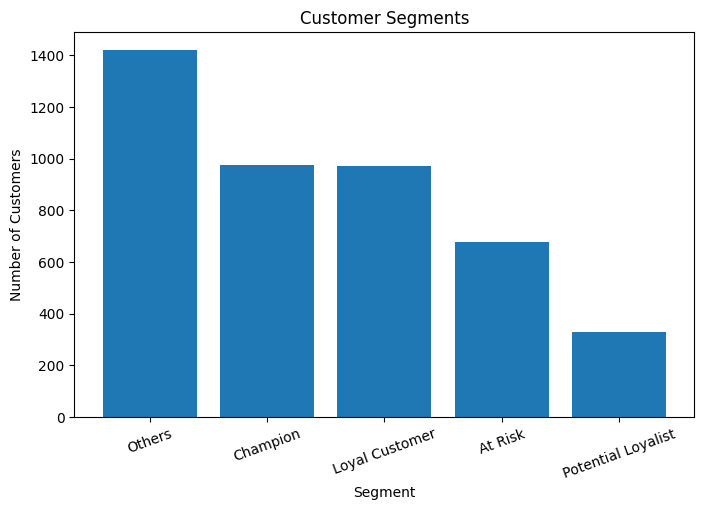

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(segment_count.index,
        segment_count.values)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

#Conclusion


In [109]:
##

#This project analyzed the Online Retail dataset to understand sales performance, customer purchasing behavior, product performance, and country-wise revenue distribution.
# Monthly sales showed strong growth during September, October, and November.
# A small number of products generated a significant portion of total revenue.
# Repeat customers contributed approximately 70% of the customer base, indicating strong customer retention.
# The United Kingdom generated the highest revenue, contributing nearly 84% of total sales.
# The top 10 countries contributed more than 97% of the overall revenue.
# RFM Analysis successfully segmented customers into Champions, Loyal Customers, Potential Loyalists, At Risk, and Others.##

### Business Recommendations

#Reward Champion customers through loyalty programs and exclusive offers.
#Re-engage At Risk customers using discounts and personalized marketing campaigns.
# Convert Potential Loyalists into Loyal Customers through targeted promotions.
#Maintain inventory for high-performing products.
# Continue strengthening the United Kingdom market while exploring growth opportunities in other countries.